<a href="https://colab.research.google.com/github/BenLeroyS/Komputasi-Statistika-Matana-/blob/main/Quiz_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00


In [ ]:
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np

In [ ]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.miHoYo.GenshinImpact"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.miHoYo.GenshinImpact


In [ ]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='en',   # Language: English
    country='us',  # Country: US
    count=200,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3b12526b-b69e-48bc-9861-a374d5a639b3,Cantoria Lucky,https://play-lh.googleusercontent.com/a/ACg8oc...,damn this good,5,0,6.4.0_42040338_42314721,2026-03-29 03:11:09,None,NaT,6.4.0_42040338_42314721
1,8ac32c23-f748-4b26-af07-c3b20cdf6662,Ainnur 15,https://play-lh.googleusercontent.com/a-/ALV-U...,I like it,5,0,6.4.0_42040338_42314721,2026-03-29 02:37:25,None,NaT,6.4.0_42040338_42314721
2,e2f9e829-dede-4663-8e98-7046d7e5e832,Anton Malofeev,https://play-lh.googleusercontent.com/a-/ALV-U...,at first it was really similar to old school f...,3,0,None,2026-03-29 02:12:11,None,NaT,None
3,8893e048-9cef-4cfd-9750-caf1b32a8b5f,Kelly Holtum,https://play-lh.googleusercontent.com/a/ACg8oc...,I love the game,4,0,6.4.0_42040338_42314721,2026-03-29 01:56:08,None,NaT,6.4.0_42040338_42314721
4,768f1200-4f75-47b4-911c-67e61b8f64a0,vodka,https://play-lh.googleusercontent.com/a-/ALV-U...,i cant login to genshin 😡 it keeps buffering i...,1,0,6.4.0_42040338_42314721,2026-03-29 01:24:07,"We sincerely apologize for this issue, Travele...",2026-03-29 01:24:50,6.4.0_42040338_42314721
...,...,...,...,...,...,...,...,...,...,...,...
195,6091de89-4a0c-4ca6-bc83-a2c3a1a3cfef,Shayon Ahmed,https://play-lh.googleusercontent.com/a-/ALV-U...,best game in the world better then wuthering w...,5,0,None,2026-03-24 17:32:17,None,NaT,None
196,0bd5158a-8c4d-4371-b260-f7d4f6215983,MD Prince,https://play-lh.googleusercontent.com/a-/ALV-U...,👑,5,0,6.4.0_42040338_42314721,2026-03-24 17:09:43,None,NaT,6.4.0_42040338_42314721
197,831dcdf5-4685-46b1-adb7-ded077f21c17,Peter Raj,https://play-lh.googleusercontent.com/a-/ALV-U...,it is the best game i have ever played from gr...,5,0,6.4.0_42040338_42314721,2026-03-24 17:08:40,None,NaT,6.4.0_42040338_42314721
198,59437913-fbd3-463e-9342-f534a3c73105,Tan Hui Ting,https://play-lh.googleusercontent.com/a-/ALV-U...,There is a bug for me apparently and I tried c...,4,0,6.4.0_42040338_42314721,2026-03-24 17:08:15,"We sincerely apologize for this issue, Travele...",2026-03-25 10:46:14,6.4.0_42040338_42314721


In [ ]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,3b12526b-b69e-48bc-9861-a374d5a639b3,damn this good,5
1,8ac32c23-f748-4b26-af07-c3b20cdf6662,I like it,5
2,e2f9e829-dede-4663-8e98-7046d7e5e832,at first it was really similar to old school f...,3
3,8893e048-9cef-4cfd-9750-caf1b32a8b5f,I love the game,4
4,768f1200-4f75-47b4-911c-67e61b8f64a0,i cant login to genshin 😡 it keeps buffering i...,1
...,...,...,...
195,6091de89-4a0c-4ca6-bc83-a2c3a1a3cfef,best game in the world better then wuthering w...,5
196,0bd5158a-8c4d-4371-b260-f7d4f6215983,👑,5
197,831dcdf5-4685-46b1-adb7-ded077f21c17,it is the best game i have ever played from gr...,5
198,59437913-fbd3-463e-9342-f534a3c73105,There is a bug for me apparently and I tried c...,4


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,damn this good,damn good
1,I like it,like
2,at first it was really similar to old school f...,first really similar old school feeling awesom...
3,I love the game,love game
4,i cant login to genshin 😡 it keeps buffering i...,cant login genshin keep buffering home screen ...
5,goog game,goog game
6,mana tombol skip storynya,mana tombol skip storynya
7,actually I love this game,actually love game
8,it is very good,good
9,All my life decision gets me reviewing Genshin...,life decision get reviewing genshin couple day...


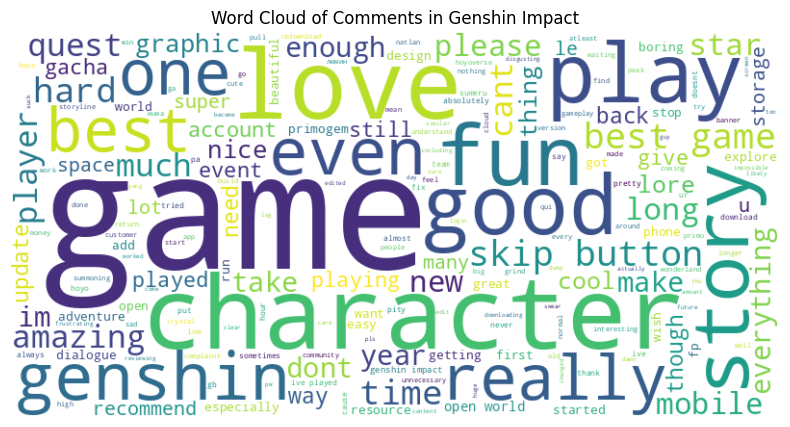

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in Genshin Impact")
plt.show()

          Word  Frequency
15        game        160
136  character         34
45        love         31
125       best         30
64         get         24
2         like         24
91         fun         22
48     genshin         22
34        play         22
1         good         22
88       story         20
143       even         17
59        skip         16
253        one         16
19      button         16
4       really         16
126       ever         15
37        time         14
30        hard         14
46        cant         12


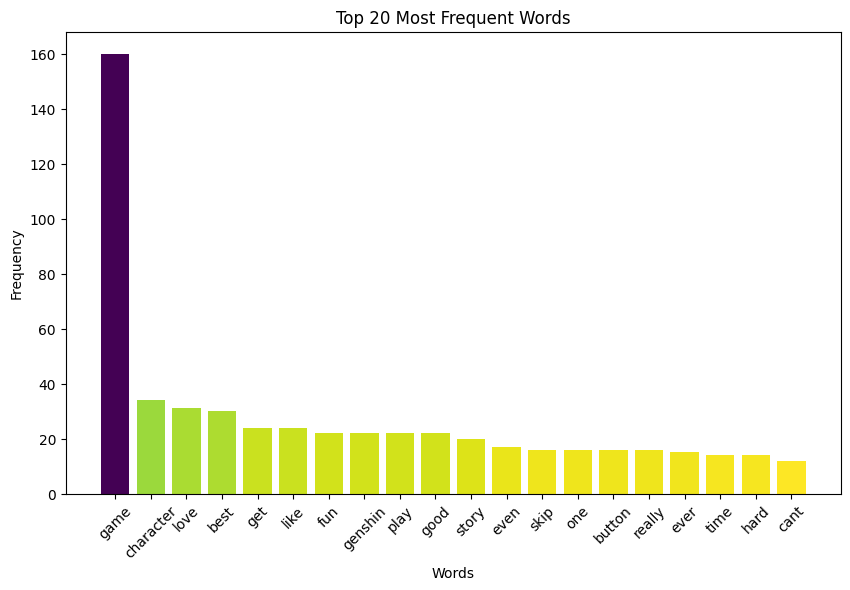

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(200, 955)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (200, 1021)
Dimensi target y: (200,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 160
Jumlah data testing: 40


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 70.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.08      0.14        13
    Positive       0.69      1.00      0.82        27

    accuracy                           0.70        40
   macro avg       0.85      0.54      0.48        40
weighted avg       0.79      0.70      0.60        40



In [ ]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "This game is a childhood masterpiece, completely love it!"
test_sentence_2 = "Too many ads and it keeps crashing on my phone. Unplayable."

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'This game is a childhood masterpiece, completely love it!'
Prediksi: Positive

Review: 'Too many ads and it keeps crashing on my phone. Unplayable.'
Prediksi: Positive


In [ ]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,damn this good,5,Positive
1,I like it,5,Positive
2,at first it was really similar to old school f...,3,Positive
3,I love the game,4,Positive
4,i cant login to genshin 😡 it keeps buffering i...,1,Negative


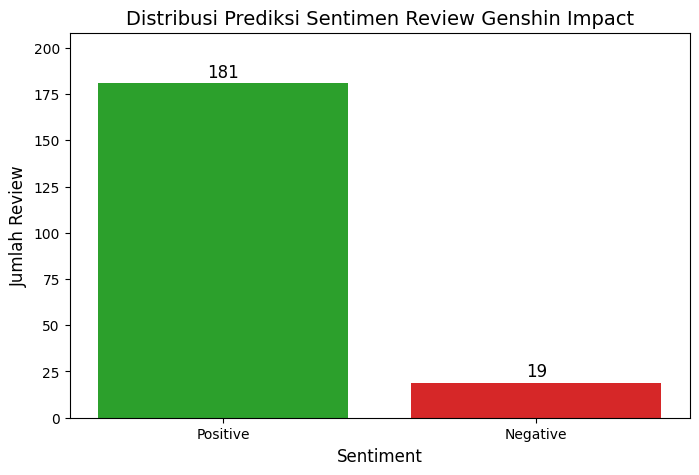

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Genshin Impact', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()